# 19c. Async Patterns for Agents

**Tier:** Agent Engineering
**Estimated time:** 40 minutes
**Prerequisites:** 19, 19b
**Priority:** 🔴 Crucial — the #1 cause of real agent failures under load is blocking code, not a missing feature; notebooks 23 (fan-out) and 29 (serving) silently assume you already know this. *If skipped, revisit when:* an agent needs to make more than one concurrent LLM/tool call, or you put an agent behind an API.
**Source material:** @sairahul1 — "How To Become an Agentic AI Engineer in 6 Months", Stage 1 & Stage 11 (https://x.com/sairahul1/status/2074790798584062278)

## What You'll Learn
- Why agent workloads are wait-bound, not compute-bound, and what that means for how you write the loop
- `asyncio.gather` to fire concurrent LLM/tool calls instead of looping one at a time
- Bounding concurrency with a semaphore, retrying flaky calls with backoff + jitter, and isolating failures so one bad call doesn't kill a batch
- Turning notebook 19's sequential tool-execution step into a concurrent one

## Why This Matters
An agent that calls a model, waits, then calls a tool, then waits again spends almost all of its wall-clock time doing nothing. That's fine for a demo with one user. It falls over the moment ten users hit your API at once, or one agent turn requests five tool calls — sequential code turns a few-second job into a request queue. This is the roadmap's own closing argument: it names blocking code as the single most common root cause of real production agent failures, ahead of missing evals or missing tracing.

## Agents spend most of their lives waiting

Every step of an agent loop involves waiting on something external: the model to respond, an API to return, a tool to finish. None of that waiting needs the CPU. A synchronous agent still blocks on it anyway — like a cook who stands at the oven watching bread rise instead of starting the next dish. An async agent starts the next request while the first is still in flight, the way a cook with four burners going keeps every one of them busy.

`asyncio` doesn't make any single call faster. A model call still takes as long as it takes. What it changes is whether *independent* calls have to wait for each other. Ten independent 2-second calls run sequentially take 20 seconds; run concurrently they take about 2, because they were never dependent on each other's results in the first place.

This only helps when calls are actually independent (fan-out over several tool calls, several sub-tasks, several users) — it does nothing for a single chain of dependent steps, since step 2 still needs step 1's result before it can start.

In [1]:
import os, time, random, asyncio
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    from anthropic import AsyncAnthropic
    async_client = AsyncAnthropic()
    print("ready — AsyncAnthropic client created")
else:
    async_client = None
    print("No ANTHROPIC_API_KEY — live cells will skip and use the mock client instead.")

ready — AsyncAnthropic client created


## A mock LLM call, offline-safe

So the timing comparisons below run the same way with or without an API key, we simulate an LLM call as a coroutine that sleeps for a bit (standing in for network + inference latency) and returns a canned answer. The blocking version does the same wait with plain `time.sleep`, so the two are a fair comparison of *the same latency* handled two different ways.

In [2]:
LATENCY_SECONDS = 0.4   # stand-in for a real model round trip

def blocking_llm_call(query):
    time.sleep(LATENCY_SECONDS)
    return f"answer to: {query}"

async def async_llm_call(query):
    await asyncio.sleep(LATENCY_SECONDS)
    return f"answer to: {query}"

queries = [f"question {i}" for i in range(8)]

# SLOW — one call at a time, each one blocks until it finishes
start = time.perf_counter()
sequential_results = [blocking_llm_call(q) for q in queries]
sequential_time = time.perf_counter() - start
print(f"sequential: {len(queries)} calls in {sequential_time:.2f}s")

sequential: 8 calls in 3.23s


In [3]:
# FAST — every call fires at once, we wait for the slowest one, not the sum of all of them.
# ipykernel already runs an event loop, so we can `await` directly at the top level of a cell —
# calling asyncio.run() here would raise "cannot be called from a running event loop".
start = time.perf_counter()
concurrent_results = await asyncio.gather(*(async_llm_call(q) for q in queries))
concurrent_time = time.perf_counter() - start
print(f"concurrent: {len(queries)} calls in {concurrent_time:.2f}s")
print(f"speedup: {sequential_time / concurrent_time:.1f}x")

concurrent: 8 calls in 0.40s
speedup: 8.0x


Same work, same per-call latency, dramatically different wall-clock time — because the concurrent version was never actually waiting on the CPU, only on the network. This is the entire idea. Everything else in this notebook is about doing this safely: not overwhelming a real API, recovering when a call fails, and not letting one bad call take down the rest.

## The same pattern against a real model

The mock proved the mechanism. Here it is against `claude-haiku-4-5` for real — a small number of genuinely independent questions, fired concurrently instead of in a loop. Kept to 3 calls to keep this cheap; the mechanism is identical at 10 or 100.

In [4]:
async def ask(question):
    if not HAS_ANTHROPIC:
        return "[skipped: no ANTHROPIC_API_KEY]"
    resp = await async_client.messages.create(
        model=TEACH_MODEL, max_tokens=100,
        messages=[{"role": "user", "content": question}],
    )
    return resp.content[0].text

live_questions = [
    "In one sentence, what is a hash map?",
    "In one sentence, what is TCP?",
    "In one sentence, what is a race condition?",
]

start = time.perf_counter()
live_answers = await asyncio.gather(*(ask(q) for q in live_questions))
live_time = time.perf_counter() - start

for q, a in zip(live_questions, live_answers):
    print(f"Q: {q}\nA: {a}\n")
print(f"{len(live_questions)} concurrent live calls in {live_time:.2f}s")

Q: In one sentence, what is a hash map?
A: A hash map is a data structure that stores key-value pairs and uses a hash function to map keys to their values for fast lookup, insertion, and deletion.

Q: In one sentence, what is TCP?
A: TCP (Transmission Control Protocol) is a reliable network communication protocol that ensures data is delivered accurately and in order between computers over the internet.

Q: In one sentence, what is a race condition?
A: A race condition occurs when multiple threads or processes access and modify shared data simultaneously, and the final result depends unpredictably on the order in which they execute.

3 concurrent live calls in 1.15s


## Bounding concurrency

Firing everything at once works for 8 calls. It does not work for 8,000 — you'll hit the provider's rate limit, or burn your entire budget in one burst. An `asyncio.Semaphore` caps how many calls are in flight at once: every coroutine has to acquire a slot before it runs, and release it when done, so the rest queue up instead of all firing simultaneously.

In [5]:
async def bounded_call(query, semaphore):
    async with semaphore:
        return await async_llm_call(query)

many_queries = [f"question {i}" for i in range(20)]

for limit in [20, 5, 2]:
    semaphore = asyncio.Semaphore(limit)
    start = time.perf_counter()
    await asyncio.gather(*(bounded_call(q, semaphore) for q in many_queries))
    elapsed = time.perf_counter() - start
    print(f"concurrency limit {limit:>2}: {len(many_queries)} calls in {elapsed:.2f}s")

concurrency limit 20: 20 calls in 0.40s


concurrency limit  5: 20 calls in 1.61s


concurrency limit  2: 20 calls in 4.01s


Lower the limit and wall-clock time rises in steps — at limit 20 every call fires in one wave (~0.4s total), at limit 5 it takes four waves (~1.6s), at limit 2 it takes ten. The semaphore trades speed for safety: pick a limit your API tier and your budget can actually sustain.

## Retrying flaky calls

Real APIs fail intermittently — a dropped connection, a rate limit, a transient 500. A tool or model call that fails once shouldn't take the whole agent down; it should retry a few times with a growing delay (so it isn't hammering an already-struggling service) plus a little randomness (so a fleet of agents doesn't all retry in lockstep and cause a new spike — this is the "jitter" in backoff-and-jitter).

In [6]:
class FlakyToolError(Exception):
    pass

_attempt_counter = {}

async def flaky_tool(query):
    # Simulates a tool that fails on its first two calls per query, then succeeds.
    _attempt_counter[query] = _attempt_counter.get(query, 0) + 1
    if _attempt_counter[query] < 3:
        raise FlakyToolError(f"transient failure on attempt {_attempt_counter[query]}")
    return f"result for: {query}"

async def call_with_retry(coro_fn, query, max_attempts=5, base_delay=0.05):
    for attempt in range(1, max_attempts + 1):
        try:
            return await coro_fn(query)
        except FlakyToolError as e:
            if attempt == max_attempts:
                raise
            delay = base_delay * (2 ** (attempt - 1)) + random.uniform(0, base_delay)
            print(f"  attempt {attempt} failed ({e}) — retrying in {delay:.3f}s")
            await asyncio.sleep(delay)

random.seed(0)
result = await call_with_retry(flaky_tool, "lookup warranty length")
print("recovered:", result)

  attempt 1 failed (transient failure on attempt 1) — retrying in 0.092s
  attempt 2 failed (transient failure on attempt 2) — retrying in 0.138s


recovered: result for: lookup warranty length


## Isolating failures in a batch

`asyncio.gather` by default does the worst possible thing on failure: the moment any one coroutine raises, the whole `gather` call raises too, and you lose every result that had already succeeded. `return_exceptions=True` fixes that — failures come back as exception objects sitting in the results list instead of crashing the batch, so you can separate the successes from the failures yourself. A timeout on each individual call (`asyncio.wait_for`) stops one hung call from stalling the whole batch.

In [7]:
async def unreliable_call(query):
    if "bad" in query:
        raise ValueError(f"permanently broken query: {query}")
    if "slow" in query:
        await asyncio.sleep(5)   # would hang the whole batch without a timeout
    await asyncio.sleep(0.05)
    return f"ok: {query}"

async def safe_call(query, per_call_timeout=0.5):
    try:
        return await asyncio.wait_for(unreliable_call(query), timeout=per_call_timeout)
    except Exception as e:
        return e   # hand the error back instead of raising, so the batch survives

batch = ["good query 1", "bad query", "good query 2", "slow query", "good query 3"]
results = await asyncio.gather(*(safe_call(q) for q in batch))

for q, r in zip(batch, results):
    status = "FAILED" if isinstance(r, Exception) else "ok"
    print(f"[{status}] {q!r} -> {r}")

succeeded = sum(1 for r in results if not isinstance(r, Exception))
print(f"\n{succeeded}/{len(batch)} calls succeeded, batch did not crash")

[ok] 'good query 1' -> ok: good query 1
[FAILED] 'bad query' -> permanently broken query: bad query
[ok] 'good query 2' -> ok: good query 2
[FAILED] 'slow query' -> 
[ok] 'good query 3' -> ok: good query 3

3/5 calls succeeded, batch did not crash


## Async-ifying notebook 19's tool-execution step

Notebook 19's loop, when the model requests several tools in one turn, ran them one after another:

```python
for block in resp.content:
    if block.type == "tool_use":
        result = impl(**block.input)
```

If those tools are independent — two different lookups, not one feeding the other — there's no reason to wait for the first to finish before starting the second. Below, the same shape runs concurrently with `asyncio.gather`, using async tool implementations and the bounded-retry, isolated-failure pieces built above.

In [8]:
# Two independent async tools, each with its own simulated latency.
async def check_stock(item):
    await asyncio.sleep(0.3)
    return f"{item}: 12 in stock"

async def check_price(item):
    await asyncio.sleep(0.3)
    return f"{item}: $49.99"

ASYNC_TOOLS = {"check_stock": check_stock, "check_price": check_price}

async def run_tool_calls_concurrently(tool_use_blocks):
    # tool_use_blocks: list of {"name": str, "input": dict, "id": str} — same shape as a real
    # Anthropic tool_use content block, just executed as a batch instead of a for-loop.
    async def run_one(block):
        impl = ASYNC_TOOLS[block["name"]]
        result = await safe_call_impl(impl, block["input"])
        return {"type": "tool_result", "tool_use_id": block["id"], "content": str(result)}

    async def safe_call_impl(impl, kwargs):
        try:
            return await asyncio.wait_for(impl(**kwargs), timeout=2.0)
        except Exception as e:
            return f"[tool error: {e}]"

    return await asyncio.gather(*(run_one(b) for b in tool_use_blocks))

# Simulating one model turn that requested two independent tool calls.
requested_calls = [
    {"name": "check_stock", "input": {"item": "Helios X1"}, "id": "call_1"},
    {"name": "check_price", "input": {"item": "Helios X1"}, "id": "call_2"},
]

start = time.perf_counter()
tool_results = await run_tool_calls_concurrently(requested_calls)
elapsed = time.perf_counter() - start

for r in tool_results:
    print(r)
print(f"\n{len(requested_calls)} tool calls resolved concurrently in {elapsed:.2f}s (sequential would be ~0.6s)")

{'type': 'tool_result', 'tool_use_id': 'call_1', 'content': 'Helios X1: 12 in stock'}
{'type': 'tool_result', 'tool_use_id': 'call_2', 'content': 'Helios X1: $49.99'}

2 tool calls resolved concurrently in 0.30s (sequential would be ~0.6s)


## Visualizing the payoff

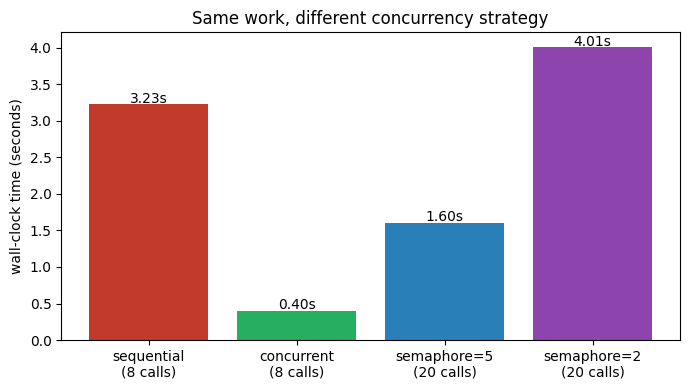

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

labels = ["sequential\n(8 calls)", "concurrent\n(8 calls)", "semaphore=5\n(20 calls)", "semaphore=2\n(20 calls)"]
times = [sequential_time, concurrent_time, None, None]

# Re-derive the two semaphore timings so the plot doesn't depend on cell run order.
async def _time_with_limit(limit, n=20):
    semaphore = asyncio.Semaphore(limit)
    start = time.perf_counter()
    await asyncio.gather(*(bounded_call(f"q{i}", semaphore) for i in range(n)))
    return time.perf_counter() - start

times[2] = await _time_with_limit(5)
times[3] = await _time_with_limit(2)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, times, color=["#c0392b", "#27ae60", "#2980b9", "#8e44ad"])
ax.set_ylabel("wall-clock time (seconds)")
ax.set_title("Same work, different concurrency strategy")
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.02, f"{t:.2f}s", ha="center")
plt.tight_layout()
plt.show()

*Sequential pays the full sum of every call's latency; full concurrency pays roughly one call's latency; a semaphore sits in between by design, trading speed for a concurrency ceiling you control.*

## Exercises

In [10]:
# Exercise 1 (Warm-up): Change the concurrency limit
# Task: Re-run the semaphore comparison cell with limits [10, 3, 1] instead of [20, 5, 2] and
#       explain in a comment why limit=1 gives the same total time as the fully sequential run.
# Hint: A semaphore of 1 means only one coroutine can hold the slot at a time — what does that
#       reduce to?

# YOUR CODE HERE

In [11]:
# Exercise 2 (Apply): Add backoff+jitter retry to the batch-isolation cell
# Task: Modify `safe_call` so that instead of catching-and-returning the exception immediately,
#       it retries the query up to 3 times with backoff+jitter (reuse `call_with_retry`'s pattern)
#       before giving up and returning the exception. Confirm "good query 1/2/3" still succeed
#       and "bad query" still fails after exhausting retries.
# Hint: `unreliable_call` always raises for "bad query" — retrying won't save it, and that's the
#       point: retry recovers from *transient* failures, not permanent ones.

# YOUR CODE HERE

In [12]:
# Exercise 3 (Extend): Make notebook 23's Fan-Out & Synthesize concurrent
# Task: Notebook 23 (Loop Engineering) implements Fan-Out & Synthesize by looping over sub-tasks
#       and calling the model once per sub-task. Sketch (in comments or code) how you'd rewrite
#       that loop using `asyncio.gather` + a semaphore, and estimate the wall-clock speedup for
#       5 sub-tasks at ~2s per call.
# Hint: The fan-out step is exactly the "independent calls" case this notebook opened with —
#       nothing about the synthesis step needs to change, only how the sub-task calls are issued.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for limit in [10, 3, 1]:
    semaphore = asyncio.Semaphore(limit)
    start = time.perf_counter()
    await asyncio.gather(*(bounded_call(q, semaphore) for q in many_queries))
    elapsed = time.perf_counter() - start
    print(f"concurrency limit {limit:>2}: {len(many_queries)} calls in {elapsed:.2f}s")
# limit=1 forces every coroutine to wait for the previous one to release the semaphore before it
# can even start — that IS the sequential loop, just written with async syntax instead of a for-loop.

# Exercise 2
async def safe_call_with_retry(query, per_call_timeout=0.5, max_attempts=3):
    for attempt in range(1, max_attempts + 1):
        try:
            return await asyncio.wait_for(unreliable_call(query), timeout=per_call_timeout)
        except Exception as e:
            if attempt == max_attempts:
                return e
            await asyncio.sleep(0.05 * (2 ** (attempt - 1)) + random.uniform(0, 0.05))

results2 = await asyncio.gather(*(safe_call_with_retry(q) for q in batch))
for q, r in zip(batch, results2):
    status = "FAILED" if isinstance(r, Exception) else "ok"
    print(f"[{status}] {q!r} -> {r}")
# good queries still succeed on the first attempt; "bad query" retries 3 times and still fails,
# because ValueError isn't transient — retrying a permanent bug just delays the same failure.

# Exercise 3
# Sketch:
# async def run_subtask(subtask, semaphore):
#     async with semaphore:
#         return await call_model_async(subtask)
#
# semaphore = asyncio.Semaphore(5)
# subtask_results = await asyncio.gather(*(run_subtask(t, semaphore) for t in subtasks))
# synthesis = synthesize(subtask_results)   # synthesis step is unchanged — it just now runs
#                                            # after all 5 sub-tasks resolve in ~2s instead of ~10s
# Estimated speedup: 5 sequential calls at 2s each = ~10s; 5 concurrent calls (limit 5) = ~2s -> ~5x.
```
</details>

## Key Takeaways
- Agent workloads are wait-bound: `asyncio` doesn't make one call faster, it lets independent calls overlap instead of queuing behind each other.
- `asyncio.gather` turns a sequential for-loop of calls into one concurrent batch — the exact fix for notebook 19's one-tool-at-a-time execution step.
- A `Semaphore` caps how much concurrency you actually use, which is what keeps you inside a rate limit and a budget, not off a cliff.
- Retry with backoff+jitter recovers from *transient* failures; `return_exceptions=True` and per-call timeouts keep one bad call from crashing an entire batch.
- This is infrastructure, not a feature — every notebook from here on (multi-agent orchestration, serving, production deployment) assumes an agent that doesn't block.

## What's Next
Notebook **20 — Multi-Agent Patterns** puts several agents to work at once — exactly the kind of independent, concurrent workload this notebook just showed you how to run safely.